## PINNs: An Example of a 1D ODE Solver

This notebook introduces the core idea of physics-informed neural networks (PINNs) through a simple ODE example. A foundational reference is the 2019 PINNs paper ([RPK19](./RPK19_PINNs.pdf)), which presents a framework for solving forward and inverse problems by embedding nonlinear partial differential equations (PDEs) into a neural network loss function.

__1D ODE__ as an example

Consider the 1D linear ODE
$$
u'(x) = a u(x) + b,\quad u(0)=c.
$$
Its exact solution is:
- If $a \neq 0$, then 
    $$u(x) = c e^{ax} + \frac{b}{a} \left(e^{ax} -1\right),$$
- If $a = 0$, then 
    $$u(x) = c + bx.$$


We use **physics-informed neural networks (PINNs)** to approximate this solution on the interval $[0,1]$.

Rewrite the ODE as
$$
F(u(x),u'(x))=0,\quad B(u(x)) = 0,
$$
where
$$
F(q, p) = aq - p+ b, B(q) = q - c.
$$

A function $u$ solves the problem if and only if
$$
G(u,u',u(0))=\|F(u,u')\|_2 + |B(u(0))|=0.
$$


To implement this idea, define a neural-network hypothesis class
$$
\mathcal{N}=\{h_\theta:\theta\in\mathbb{R}^m\},
$$
and determine $\theta^*$ by minimizing
$$
\theta^*=\arg\min_\theta\, G\!\left(h_\theta,h'_\theta,h_\theta(0)\right).
$$

Then $h_{\theta^*}$ serves as the PINN approximation of $u$.

In [1]:
# code starts here
import torch

import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# Reproducibility
torch.manual_seed(42)

In [2]:

# PINN model
class PINN(nn.Module):
    def __init__(self, hidden=32, depth=3):
        super().__init__()
        layers = [nn.Linear(1, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


In [3]:

def ode_1d_solver(a, b, c, epochs=5000, lr=1e-3, hidden=32, depth=3):
    """
    Solves the ODE u' = a*u + b with u(0)=c using a PINN.
    """
    model = PINN(hidden=hidden, depth=depth)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Collocation points in [0, 1]
    x_f = torch.linspace(0, 1, 200).view(-1, 1)
    x_f.requires_grad_(True)

    # Boundary point x=0
    x0 = torch.tensor([[0.0]])

    # Training
    for epoch in range(epochs):
        optimizer.zero_grad()

        u = model(x_f)
        du_dx = torch.autograd.grad(
            u, x_f, grad_outputs=torch.ones_like(u), create_graph=True
        )[0]

        # ODE residual: au - u' + b = 0
        f = a*u - du_dx + b
        loss_pde = torch.mean(f**2)

        # Boundary condition: u(0) -c = 0
        u0 = model(x0)
        loss_bc = (u0 - c).pow(2).mean()

        loss = loss_pde + loss_bc
        loss.backward()
        optimizer.step()

        if epoch % 500 == 0:
            print(f"Epoch {epoch:4d} | Loss: {loss.item():.6e}")
    return model


In [4]:
# Problem setup
# ODE: u' = a u + b with u(0) = c
a = 2.0
b = 1.0
c = -1.0
# run the solver
model = ode_1d_solver(a, b, c)

Epoch    0 | Loss: 1.934919e+00
Epoch  500 | Loss: 1.572208e-01
Epoch 1000 | Loss: 4.385436e-04
Epoch 1500 | Loss: 8.155969e-05
Epoch 2000 | Loss: 4.167562e-05
Epoch 2500 | Loss: 3.809777e-05
Epoch 3000 | Loss: 1.981980e-04
Epoch 3500 | Loss: 2.107754e-05
Epoch 4000 | Loss: 1.982709e-05
Epoch 4500 | Loss: 5.844943e-05


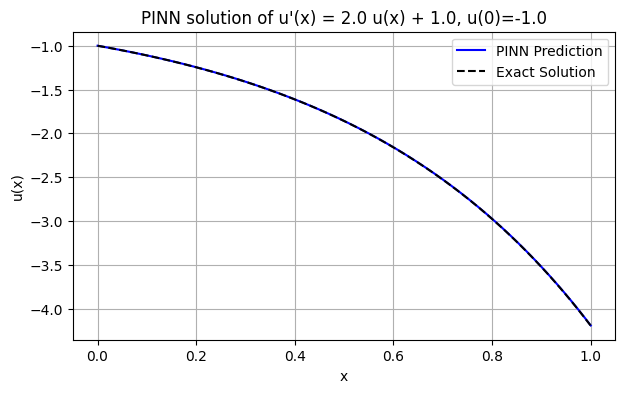

In [5]:
# Check the solution
x_test = torch.linspace(0, 1, 100).view(-1, 1)
u_pred = model(x_test).detach().numpy()
x_test_np = x_test.numpy()

# Correct exact solution: u(x) = (c + b/a) * exp(ax) - b/a
u_exact = (c + b/a) * np.exp(a * x_test_np) - b/a

plt.figure(figsize=(7, 4))
plt.plot(x_test_np, u_pred, "b", label='PINN Prediction')
plt.plot(x_test_np, u_exact, "k--", label='Exact Solution')
plt.legend()
plt.title(f"PINN solution of u'(x) = {a} u(x) + {b}, u(0)={c}")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.grid(True)
plt.show()